In [9]:
import joblib
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("="*60)
print("BOOSTING EXPERIMENT + THRESHOLD OPTIMIZATION")
print("="*60)

BOOSTING EXPERIMENT + THRESHOLD OPTIMIZATION


In [10]:
print("\n[LOAD DATA]")

X_train_resampled = joblib.load('X_train_resampled_values_v1.pkl')
y_train_resampled = joblib.load('y_train_resampled_values_v1.pkl')
X_test = joblib.load('X_test_values_v1.pkl')
y_test = joblib.load('y_test_values_v1.pkl')

print("Train:", X_train_resampled.shape)
print("Test :", X_test.shape)


[LOAD DATA]
Train: (8896112, 10)
Test : (1908786, 10)


In [ ]:
models = {
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        booster = "gbtree",
        n_estimators=100,
        random_state=42,
        device="cuda",
        tree_method="hist",
        eval_metric="logloss"
    ),

    "XGBoostLinear": XGBClassifier(
        booster = "gblinear",
        n_estimators=100,
        random_state=42,
        device="cuda",
        eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        
        n_estimators=100,
        random_state=42,
        device="gpu",
        verbose=-1
    ),
    "LightGBM_RF": LGBMClassifier(
        boosting_type="rf",
        n_estimators=100,
        bagging_freq=1,
        bagging_fraction=0.8,
        feature_fraction=0.8,
        random_state=42,
        device="gpu",
        verbose=-1
    )
}

In [12]:
def plot_cm(cm, name, dtype):
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['0', '1'],
        yticklabels=['0', '1']
    )

    plt.title(f"{name} - {dtype}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/cm_{name}_{dtype}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [13]:
trained_models = {}

print("\n[TRAINING MODELS]")

for name, model in models.items():
    print("\n==", name, "==")

    start = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    print("Train time:", round(time.time() - start, 2), "sec")

    trained_models[name] = model

    joblib.dump(model, f"{name}_model.pkl")


[TRAINING MODELS]

== GradientBoosting ==
Train time: 1596.71 sec

== XGBoost ==
Train time: 5.24 sec

== XGBoostLinear ==
Train time: 25.83 sec

== LightGBM ==
Train time: 15.91 sec

== LightGBM_RF ==
Train time: 17.46 sec


In [14]:
from sklearn.metrics import precision_recall_curve
def three_different_threshold_evaluation(model,X,y):
    proba = model.predict_proba(X)[:, 1]

    default_t = 0.5

    loop_t = 0.5
    best_f1_loop = 0

    for t in np.linspace(0.01, 0.99, 200):
        pred = (proba >= t).astype(int)
        f1 = f1_score(y, pred)

        if f1 > best_f1_loop:
            best_f1_loop = f1
            loop_t = t
    
  

    return default_t,loop_t

In [15]:
thresholds = {}

print("\n[THRESHOLD OPTIMIZATION]")

for name, model in trained_models.items():
    print("\n==", name, "==")

    # Ambil 3 threshold sekaligus dari fungsi
    t_default, t_loop= three_different_threshold_evaluation(model, X_test, y_test)

    # Simpan ketiganya ke dalam dictionary berdasarkan nama model
    thresholds[name] = {
        "default": t_default,
        "otomatis": t_loop,
        
    }

    # Cetak hasilnya agar bisa kamu bandingkan langsung
    print("Threshold Default  :", round(t_default, 3))
    print("Threshold Otomatis :", round(t_loop, 3))
   


[THRESHOLD OPTIMIZATION]

== GradientBoosting ==


ValueError: not enough values to unpack (expected at least 1, got 0)

ValueError: not enough values to unpack (expected at least 1, got 0)

ValueError: not enough values to unpack (expected at least 1, got 0)

ValueError: not enough values to unpack (expected at least 1, got 0)

Threshold Default  : 0.5
Threshold Otomatis : 0.985

== XGBoost ==
Threshold Default  : 0.5
Threshold Otomatis : 0.99

== XGBoostLinear ==
Threshold Default  : 0.5
Threshold Otomatis : 0.99

== LightGBM ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Default  : 0.5
Threshold Otomatis : 0.99

== LightGBM_RF ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Default  : 0.5
Threshold Otomatis : 0.867



[FINAL EVALUATION]

== GradientBoosting ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)
METRICS:
  Accuracy : 0.9818
  Precision: 0.0651
  Recall   : 0.9938
  AUC Score: 0.9974
  F1 Test  : 0.1222

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9818    0.9908   1906351
           1     0.0651    0.9938    0.1222      2435

    accuracy                         0.9818   1908786
   macro avg     0.5326    0.9878    0.5565   1908786
weighted avg     0.9988    0.9818    0.9897   1908786



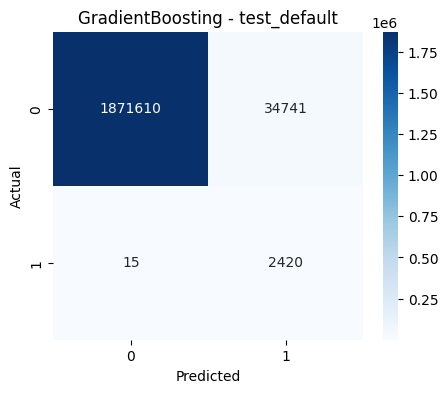


>> Menilai Menggunakan Threshold: OTOMATIS (0.985)
METRICS:
  Accuracy : 0.9995
  Precision: 0.865
  Recall   : 0.7446
  AUC Score: 0.9974
  F1 Test  : 0.8003

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1906351
           1     0.8650    0.7446    0.8003      2435

    accuracy                         0.9995   1908786
   macro avg     0.9323    0.8722    0.9000   1908786
weighted avg     0.9995    0.9995    0.9995   1908786



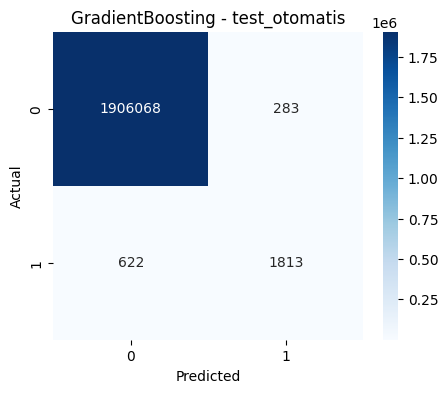


== XGBoost ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)
METRICS:
  Accuracy : 0.997
  Precision: 0.2937
  Recall   : 0.9803
  AUC Score: 0.9935
  F1 Test  : 0.452

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9970    0.9985   1906351
           1     0.2937    0.9803    0.4520      2435

    accuracy                         0.9970   1908786
   macro avg     0.6468    0.9886    0.7252   1908786
weighted avg     0.9991    0.9970    0.9978   1908786



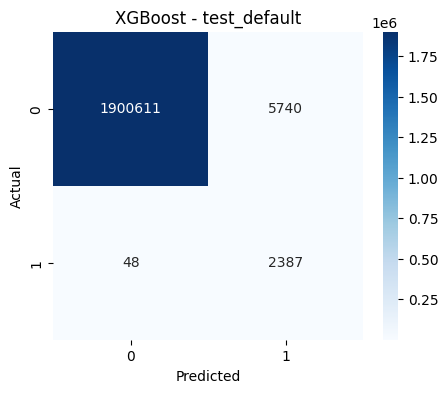


>> Menilai Menggunakan Threshold: OTOMATIS (0.99)
METRICS:
  Accuracy : 0.9993
  Precision: 0.6937
  Recall   : 0.8304
  AUC Score: 0.9935
  F1 Test  : 0.7559

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9997   1906351
           1     0.6937    0.8304    0.7559      2435

    accuracy                         0.9993   1908786
   macro avg     0.8467    0.9150    0.8778   1908786
weighted avg     0.9994    0.9993    0.9993   1908786



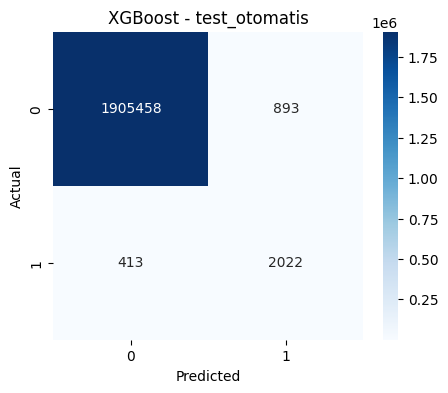


== XGBoostLinear ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)
METRICS:
  Accuracy : 0.9401
  Precision: 0.0191
  Recall   : 0.9101
  AUC Score: 0.985
  F1 Test  : 0.0373

  Classification Report (default):
              precision    recall  f1-score   support

           0     0.9999    0.9402    0.9691   1906351
           1     0.0191    0.9101    0.0373      2435

    accuracy                         0.9401   1908786
   macro avg     0.5095    0.9251    0.5032   1908786
weighted avg     0.9986    0.9401    0.9679   1908786



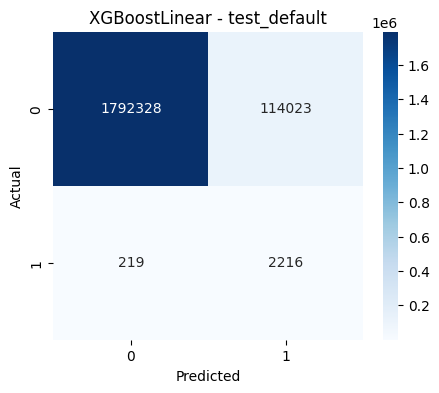


>> Menilai Menggunakan Threshold: OTOMATIS (0.99)
METRICS:
  Accuracy : 0.9985
  Precision: 0.4107
  Recall   : 0.4493
  AUC Score: 0.985
  F1 Test  : 0.4291

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9993    0.9992    0.9992   1906351
           1     0.4107    0.4493    0.4291      2435

    accuracy                         0.9985   1908786
   macro avg     0.7050    0.7242    0.7142   1908786
weighted avg     0.9985    0.9985    0.9985   1908786



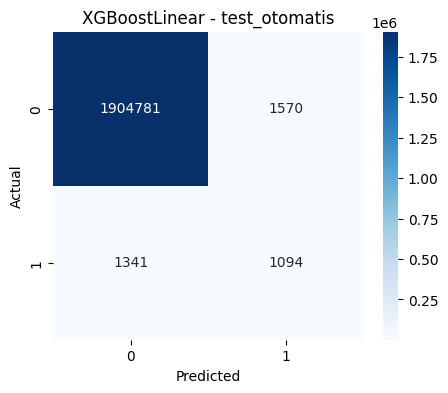


== LightGBM ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9966
  Precision: 0.272
  Recall   : 0.9947
  AUC Score: 0.9994
  F1 Test  : 0.4272

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9966    0.9983   1906351
           1     0.2720    0.9947    0.4272      2435

    accuracy                         0.9966   1908786
   macro avg     0.6360    0.9956    0.7128   1908786
weighted avg     0.9991    0.9966    0.9976   1908786



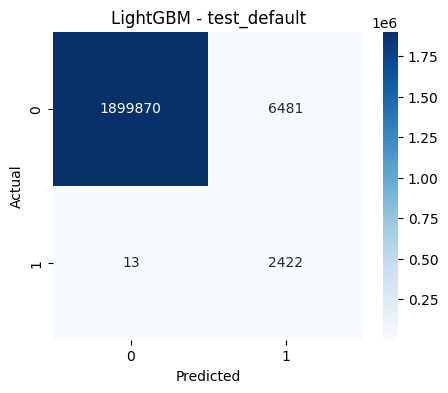


>> Menilai Menggunakan Threshold: OTOMATIS (0.99)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9996
  Precision: 0.8736
  Recall   : 0.8259
  AUC Score: 0.9994
  F1 Test  : 0.8491

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998   1906351
           1     0.8736    0.8259    0.8491      2435

    accuracy                         0.9996   1908786
   macro avg     0.9367    0.9129    0.9244   1908786
weighted avg     0.9996    0.9996    0.9996   1908786



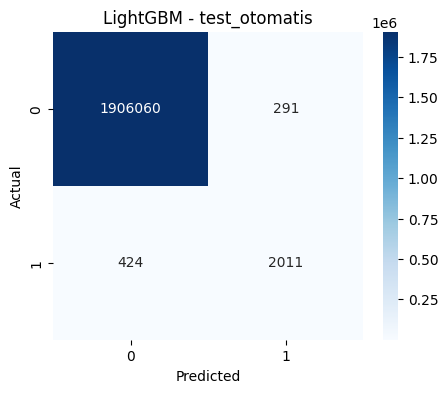


== LightGBM_RF ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9868
  Precision: 0.0876
  Recall   : 0.9955
  AUC Score: 0.9985
  F1 Test  : 0.161

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9868    0.9933   1906351
           1     0.0876    0.9955    0.1610      2435

    accuracy                         0.9868   1908786
   macro avg     0.5438    0.9911    0.5772   1908786
weighted avg     0.9988    0.9868    0.9923   1908786



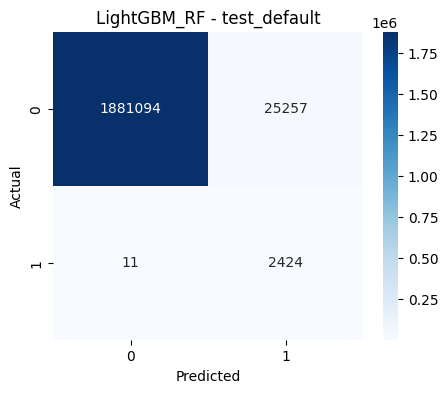


>> Menilai Menggunakan Threshold: OTOMATIS (0.867)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9996
  Precision: 0.9648
  Recall   : 0.6986
  AUC Score: 0.9985
  F1 Test  : 0.8104

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998   1906351
           1     0.9648    0.6986    0.8104      2435

    accuracy                         0.9996   1908786
   macro avg     0.9822    0.8493    0.9051   1908786
weighted avg     0.9996    0.9996    0.9995   1908786



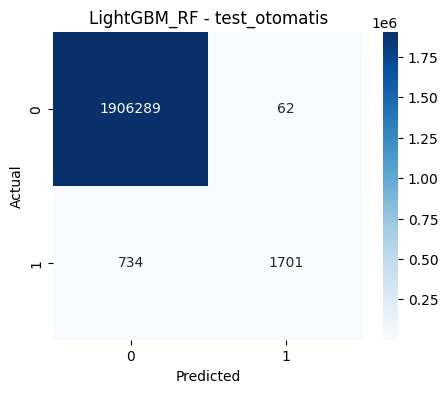

In [16]:
print("\n[FINAL EVALUATION]")

for name, model in trained_models.items():
    print("\n==============================")
    print("==", name, "==")
    print("==============================")

    # Lakukan looping untuk setiap jenis threshold yang disimpan
    for t_type, t_value in thresholds[name].items():
        print(f"\n>> Menilai Menggunakan Threshold: {t_type.upper()} ({round(t_value, 3)})")

        proba_test = model.predict_proba(X_test)[:, 1]
        pred_test = (proba_test >= t_value).astype(int)

      

        acc = accuracy_score(y_test, pred_test)
        prec = precision_score(y_test, pred_test)
        rec = recall_score(y_test, pred_test)
        f1 = f1_score(y_test, pred_test)
     
        
        auc_score = 0.0
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            auc_score = roc_auc_score(y_test, y_proba)

        print("METRICS:")
        print("  Accuracy :", round(acc, 4))
        print("  Precision:", round(prec, 4))
        print("  Recall   :", round(rec, 4))
        print("  AUC Score:", round(auc_score, 4))
        print("  F1 Test  :", round(f1, 4))
       

        # Jika dirasa terlalu penuh, classification report & plot_cm bisa ditaruh 
        # di luar loop threshold atau hanya dijalankan untuk t_type == 'manual' saja.
        print(f"\n  Classification Report ({t_type}):")
        print(classification_report(y_test, pred_test, digits=4))

        cm_test = confusion_matrix(y_test, pred_test)
       

        plot_cm(cm_test, name, f"test_{t_type}")
      

    # Eksport model cukup sekali saja per tipe model (di luar loop threshold)
    joblib.dump(model, f"{name}_final.pkl")